In [1]:
import os
from dotenv import load_dotenv
print(load_dotenv())

True


# Stuff Document Chain
**"모든 문서를 한 번에 프롬프트에 넣기"**

![](https://publish-01.obsidian.md/access/84bff78007c07f71220692232b80322e/Study/LangChain/Reference/RAG%20Reference/Stufff%20Chain%20Process.jpg)

```
[문서1] + [문서2] + [문서3] + [질문] → LLM → 답변
```

검색된 모든 문서를 하나의 프롬프트에 그대로 집어넣어 한 번의 LLM 호출로 답변을 생성합니다.

| 장점 | 단점 |
|------|------|
| 구현이 단순하고 빠름 | 문서가 많으면 컨텍스트 길이 초과 |
| LLM이 전체 맥락을 한번에 파악 | 토큰 비용 증가 |
| 가장 낮은 레이턴시 | 긴 문서에 부적합 |

> 소량의 짧은 문서에 최적. **가장 기본적인 방식**


In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

# 1. 모델 및 프롬프트 설정
llm = ChatOpenAI(model="gpt-4o")

prompt = ChatPromptTemplate.from_template("""
다음 제공된 문맥(context)만을 사용하여 질문에 답하세요:
{context}

질문: {question}
""")

# Retrieve 된 Document 들
docs = [
    Document(page_content="사과는 견문색 과일입니다."),
    Document(page_content="바나나는 패왕색 과일입니다."),
]

# Retrieve된 Document들을 하나의 str으로 합치는 함수
# def format_docs(docs):
#     return "\n\n".join(doc.page_content for doc in docs)
def format_docs(inputs):
    return "\n\n".join(doc.page_content for doc in inputs['documents'])

chain = (
    # {
    #     "context": lamda x: format_docs(c["documents"]),
    #     "question": lamda x: x["question"],  # 질문은 그대로 질문
    # }
    RunnablePassthrough.assign(context=format_docs)
    | prompt
    | llm
)

# 호출
response = chain.invoke({
    "documents": docs,  # list[Document]
    "question": "사과와 바나나는 각각 무슨 색 인가요?"
})

print(response.content)



사과는 견문색이고, 바나나는 패왕색입니다.


# Map-Reduce Chain
**"각 문서를 개별 요약 후 최종 합산"**

![](https://www.dropbox.com/scl/fi/tcucb37mbys2ptyddc2i8/chain_map_reduce.png?rlkey=6kygllnh8ly927h79zecs9m10&st=113d42y3&dl=1)

```
[문서1] → LLM → 중간답변1 ┐
[문서2] → LLM → 중간답변2 ┼→ LLM → 최종 답변
[문서3] → LLM → 중간답변3 ┘
```

**Map 단계**: 각 문서에 대해 독립적으로 LLM을 호출해 중간 답변 생성  
**Reduce 단계**: 모든 중간 답변을 합쳐 최종 답변 생성

| 장점 | 단점 |
|------|------|
| 문서 수에 제한 없음 | LLM 호출 횟수 많음 (비용↑) |
| 병렬 처리 가능 (Map 단계) | 레이턴시 높음 |
| 대용량 문서에 적합 | 문서 간 연관성 파악 어려움 |

> 문서가 많고 병렬 처리가 가능할 때 사용


In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableMap, RunnableLambda
from langchain_openai import ChatOpenAI
from langchain_text_splitters.character import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# LLM 정의
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# --------------------
# 1. MAP 단계 Prompt
# --------------------

map_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 문서를 요약하는 AI입니다."),
    ("human", "다음 문서를 핵심만 요약하세요:\n\n{document}")
])

map_chain = (
    map_prompt
    | llm
    | StrOutputParser()
)

# --------------------
# 2. REDUCE 단계 Prompt
# --------------------

reduce_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 여러 요약을 하나의 요약으로 통합하는 AI입니다."),
    ("human", "다음 요약들을 하나의 간결한 요약으로 통합하세요:\n\n{summaries}")
])

reduce_chain = (
    reduce_prompt
    | llm
    | StrOutputParser()
)

# --------------------
# 3. Map-Reduce LCEL 체인
# --------------------

map_reduce_chain =(
    # MAP 단계: 각 Document에 map_chain 적용
    RunnableLambda(  # 사용자 정의 함수를 체인의 요소로 사용할 수 있게 함
        lambda docs: [map_chain.invoke({"document": doc.page_content}) for doc in docs]
    )
    # REDUCE 단계
    | RunnableLambda(
        lambda summaries: reduce_chain.invoke({"summaries": "\n\n".join(summaries)})
    )
)


# --------------------
# 4. 테스트용 문서 준비
# --------------------
documents = [
    Document(page_content="LangChain은 LLM 애플리케이션을 구축하기 위한 프레임워크입니다."),
    Document(page_content="LCEL은 LangChain에서 체인을 선언적으로 구성할 수 있도록 도와줍니다."),
    Document(page_content="Map-Reduce 체인은 대규모 문서를 효율적으로 요약하는 데 유용합니다.")
]

# --------------------
# 5. 실행
# --------------------

result = map_reduce_chain.invoke(documents)
print(result)

LangChain은 LLM 애플리케이션 개발을 위한 프레임워크로, LCEL을 통해 체인을 선언적으로 구성할 수 있으며, Map-Reduce 체인은 대규모 문서의 효율적인 요약에 유용합니다.


위 수행결과를 보면 Document 들에 대한 병렬 호출이 이루어지지 않고 있다

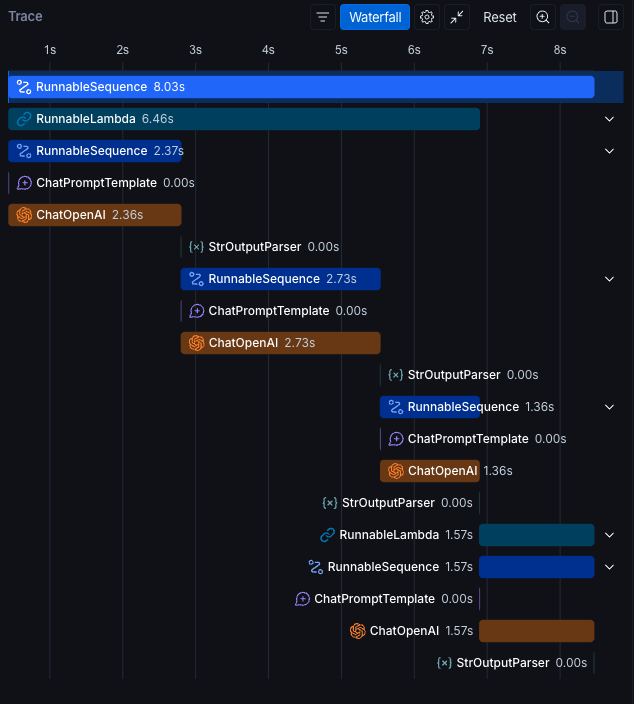

## RunnableParallel 사용 : 병렬호출

In [13]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnableLambda
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

# LLM 정의
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# --------------------
# 1. MAP 단계 Prompt
# --------------------
map_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 문서를 요약하는 AI입니다."),
    ("human", "다음 문서를 핵심만 요약하세요:\n\n{document}")    
])

map_chain = (
    map_prompt
    | llm
    | StrOutputParser()
)

# --------------------
# 2. REDUCE 단계 Prompt
# --------------------
reduce_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 여러 요약을 하나의 요약으로 통합하는 AI입니다."),
    ("human", "다음 요약들을 하나의 간결한 요약으로 통합하세요:\n\n{summaries}")    
])

reduce_chain = (
    reduce_prompt
    | llm
    | StrOutputParser()
)

# --------------------
# 3. Map-Reduce LCEL 체인
# --------------------

map_reduce_chain = (
    # 3-1. 입력된 Document 목록에서 텍스트만 추출하여 리스트로 만듭니다.
    RunnableLambda(
        lambda docs: [{"document": doc.page_content} for doc in docs]
    )
    
    # 3-2. RunnableMap(또는 .map())을 사용하여 각 문서에 대해 map_chain을 '병렬'로 실행합니다.
    # LangChain의 모든 Runnable 객체는 .map() 메서드를 지원합니다. 
    # 기존에 for 루프를 돌며 동기적으로 하나씩 처리하던 방식과 달리, 
    # map()을 사용하면 내부적으로 자동 병렬 처리가 이루어져 실행 속도가 훨씬 빨라집니다.
    | map_chain.map()

    # 3-3. 생성된 요약 리스트를 reduce_chain이 원하는 'summaries' 키를 가진 딕셔너리(RunnableMap 형태)로 변환합니다.
    # reduce_chain은 {"summaries": "텍스트"} 형태의 딕셔너리 입력을 기대합니다. 
    # RunnableMap({"summaries": ...})을 배치함으로써 직전 단계에서 넘어온 요약 배열(summaries)을 하나의 문자열로 결합하고, 
    # 이를 reduce_chain에 규격에 맞게 매핑하여 던져줍니다. (참고: RunnableMap은 RunnableParallel과 동일한 역할을 합니다.) 
    | RunnableParallel({
         "summaries": RunnableLambda(lambda summaries: "\n\n".join(summaries))   
    })

    # 3-4 최종 통합 요약 체인 실행
    | reduce_chain
)

# --------------------
# 4. 테스트용 문서 준비
# --------------------
documents = [
    Document(page_content="LangChain은 LLM 애플리케이션을 구축하기 위한 프레임워크입니다."),
    Document(page_content="LCEL은 LangChain에서 체인을 선언적으로 구성할 수 있도록 도와줍니다."),
    Document(page_content="Map-Reduce 체인은 대규모 문서를 효율적으로 요약하는 데 유용합니다.")
]

# --------------------
# 5. 실행
# --------------------

result = map_reduce_chain.invoke(documents)
print(result)


LangChain은 LLM 애플리케이션 개발을 위한 프레임워크로, LCEL 도구를 통해 체인을 선언적으로 구성할 수 있으며, Map-Reduce 체인은 대규모 문서의 효율적인 요약에 유용합니다.


이제 Map 단계는 병렬로 진행된다

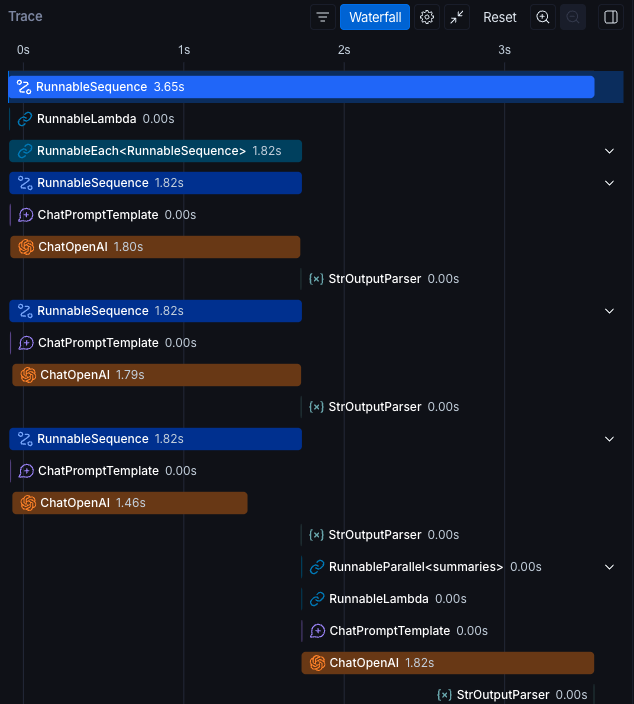

# Map-Rerank Chain
**"각 문서로 답변 생성 후 가장 확신 높은(Score 가 높은) 답변 선택"**

![](https://www.dropbox.com/scl/fi/x5ihbsscafhtafve5bctw/chain_map_rerank.png?rlkey=hkw0mxbnjoggen23pzmz67s84&st=nf5smeno&dl=1)

```
[문서1] → LLM → (답변1, 확신도: 90%) ┐
[문서2] → LLM → (답변2, 확신도: 60%) ┼→ 최고 점수 선택 → 최종 답변
[문서3] → LLM → (답변3, 확신도: 75%) ┘
```

각 문서마다 LLM이 답변과 함께 **확신도 점수**를 반환하고, 가장 높은 점수의 답변을 최종 선택합니다.

| 장점 | 단점 |
|------|------|
| 가장 관련성 높은 답변 선택 | LLM 호출 횟수 많음 |
| 노이즈 문서 영향 최소화 | 확신도 점수가 항상 정확하지 않음 |
| 단일 정답이 명확할 때 유리 | 문서 간 종합이 필요한 경우 부적합 |

> 정답이 특정 문서 하나에 집중되어 있을 때 유리



In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
import re

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

output_parser = StrOutputParser()

#-------------------------------
# Map 단계
#-------------------------------
map_prompt = ChatPromptTemplate.from_template(
    """
    너는 질문-응답 평가 모델이다.

    질문:
    {question}

    문서:
    {context}

    위 문서를 기반으로 질문에 답하라.
    그리고 답변의 질문 관련성을 0~100 사이의 점수로 평가하라.

    반드시 아래 형식으로만 출력하라:
    score: <점수>
    answer: <답변>    
    """
)

map_chain = (
    map_prompt
    | llm
    | output_parser
)

#-------------------------------
# Retrieve 된 Document 들
#-------------------------------
documents = [
    Document(page_content="LangChain은 LLM 애플리케이션 프레임워크이다."),
    Document(page_content="LCEL은 LangChain의 선언형 체인 문법이다."),
    Document(page_content="Map-Rerank는 문서별 점수를 비교하는 체인이다.")
]

question = "LangChain의 LCEL은 무엇인가?"

map_results = [
    map_chain.invoke({
        "question": question,
        "context": doc.page_content,
    })
    for doc in documents
]


# print(map_results)

def parse_result(text: str):
    score_match = re.search(r"score:\s*(\d+)", text)
    answer_match = re.search(r"answer:\s*(.*)", text, re.DOTALL)  #  re.DOTALL 는 "." 이 줄바꿈 문자(\n)도 포함해서 매칭

    return {
        "score": int(score_match.group(1)),
        "answer": answer_match.group(1).strip()
    }

parsed_results = [
    parse_result(r)
    for r in map_results
]

# print(parsed_results)

best_result = max(parsed_results, key=lambda x: x['score'])

# 최종 결과 출력
print("✅ 최종 선택된 답변")
print("Score:", best_result["score"])
print("Answer:", best_result["answer"])


✅ 최종 선택된 답변
Score: 100
Answer: LCEL은 LangChain의 선언형 체인 문법입니다.


## RunnbleParallel 사용

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
import re
from langchain_core.runnables import RunnableLambda, RunnableParallel

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

output_parser = StrOutputParser()

#-------------------------------
# Map 단계
#-------------------------------
map_prompt = ChatPromptTemplate.from_template(
    """
    너는 질문-응답 평가 모델이다.

    질문:
    {question}

    문서:
    {context}

    위 문서를 기반으로 질문에 답하라.
    그리고 답변의 질문 관련성을 0~100 사이의 점수로 평가하라.

    반드시 아래 형식으로만 출력하라:
    score: <점수>
    answer: <답변>    
    """
)

map_chain = (
    map_prompt
    | llm
    | output_parser
)

#-------------------------------
# Rerank 단계 파싱 및 정렬 함수
#-------------------------------

def parse_and_rerank(inputs):
    map_outputs = inputs['map_outputs']  # map_chain 호출 결과들의 list
    parsed_results = []

    for text in map_outputs:
        score_match = re.search(r"score:\s*(\d+)", text)
        answer_match = re.search(r"answer:\s*(.*)", text, re.DOTALL)

        if score_match and answer_match:
            parsed_results.append(
                {
                    "score": int(score_match.group(1)),
                    "answer": answer_match.group(1).strip(),
                }
            )

    # 점수가 가장 높은 결과 반환
    if not parsed_results:
        return {"score": 0, "answer": "답변을 찾을 수 없습니다."}

    return max(parsed_results, key=lambda x: x["score"])


map_rerank_chain = (
    # MAP 단계
    RunnableParallel(
        # map_outputs라는 키값에 담아서 전달
        map_outputs = RunnableLambda(
            lambda x: map_chain.batch(
                [
                    {"question": x["question"], "context": doc.page_content}
                    for doc in x['documents']
                ]
            )
        )
    )
    # Rerank 단계
    | RunnableLambda(
        parse_and_rerank
    )
)

#-------------------------------
# Retrieve 된 Document 들
#-------------------------------
documents = [
    Document(page_content="LangChain은 LLM 애플리케이션 프레임워크이다."),
    Document(page_content="LCEL은 LangChain의 선언형 체인 문법이다."),
    Document(page_content="Map-Rerank는 문서별 점수를 비교하는 체인이다.")
]

question = "LangChain의 LCEL은 무엇인가?"


# 최종 체인 호출
final_result = map_rerank_chain.invoke(
    {"question": question, "documents": documents}
)

# 최종 결과 출력
print("✅ 최종 선택된 답변")
print("Score:", final_result["score"])
print("Answer:", final_result["answer"])

✅ 최종 선택된 답변
Score: 100
Answer: LCEL은 LangChain의 선언형 체인 문법입니다.


Map 단계가 병렬로 진행

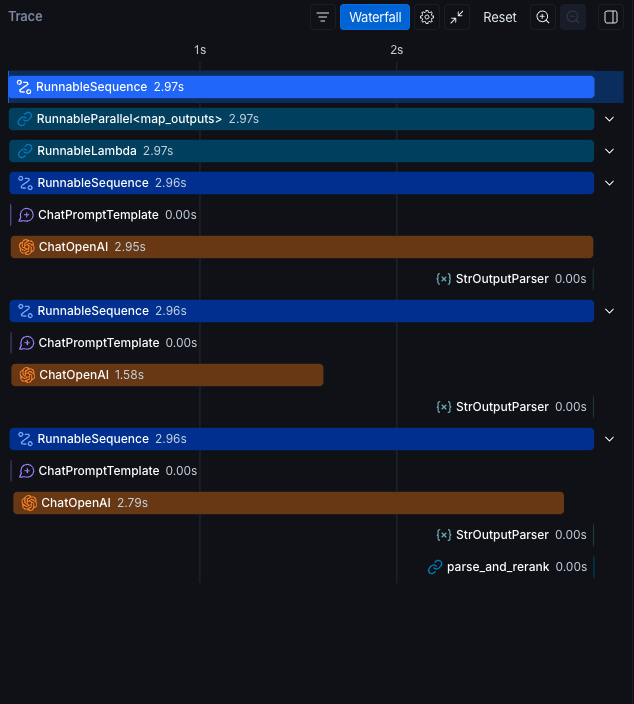

# Refine Document Chain

**"문서를 순차적으로 읽으며 답변을 점진적으로 개선"**

![](https://www.dropbox.com/scl/fi/77vb082uo1g4n2n4muqwn/chain_refine.png?rlkey=uywjls0hzefaw1ubuks6le47x&st=sovw6cd1&dl=1)

```
[문서1] → LLM → 초안 답변
         ↓
[문서2] + 초안 → LLM → 개선된 답변
                  ↓
         [문서3] + 개선된 답변 → LLM → 최종 답변
```

첫 번째 문서로 초안을 만들고, 이후 문서를 하나씩 읽으면서 답변을 지속적으로 **정제(Refine)**합니다.

| 장점 | 단점 |
|------|------|
| 문서 간 정보를 유기적으로 통합 | 순차 처리라 병렬화 불가 |
| 복잡한 질문에 높은 품질 | 레이턴시가 가장 높음 |
| 컨텍스트를 점진적으로 축적 | 초반 문서가 결과에 더 큰 영향 |

> 여러 문서의 정보를 종합해야 하는 복잡한 질문에 적합



In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# 1. LLM 정의
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# 2. 초기 답변용 프롬프트
initial_prompt = PromptTemplate.from_template(
    """
    다음 문서를 기반으로 질문에 대한 답변을 작성하세요.

    문서:
    {context}

    질문:
    {question}

    답변:
    """
)

# 초기 체인 (첫번째 문서 용)
initial_chain = (
    initial_prompt
    | llm
    | StrOutputParser()
)


# 3. Refine 프롬프트 
refine_prompt = PromptTemplate.from_template(
    """
    기존 답변:
    {existing_answer}

    아래 문서를 참고하여 기존 답변을 개선하세요.
    만약 도움이 되지 않으면 기존 답변을 그대로 유지하세요.

    문서:
    {context}

    질문:
    {question}

    개선된 답변:
    """
)

# refine 체인 (두번째 문서부터 적용)
refine_chain = (
    refine_prompt
    | llm
    | StrOutputParser()
)

def refine_documents(inputs):
    docs = inputs['documents']
    question = inputs['question']

    # 첫 문서로 초기 답변 생성
    answer = initial_chain.invoke({
        "context": docs[0].page_content,  # ✨첫번째 문서
        "question": question,
    })

    # 나머지 문서들, 순차적으로 개선 (refine)
    for doc in docs[1:]:  # ✨ 두번째 문서부터!
        answer = refine_chain.invoke({   # 체인 호출 결과로 기존의 답변 업데이트
            "existing_answer": answer,   # 기존의 답변 전달!
            "context": doc.page_content, 
            "question": question,
        })

    return answer
    

#  전체 chain
refine_document_chain = RunnableLambda(refine_documents)


# ======================
# 사용 
# ======================
documents = [
    Document(page_content="LangChain은 LLM 애플리케이션을 구축하기 위한 프레임워크이다."),
    Document(page_content="LCEL은 체인을 선언적으로 구성할 수 있게 해준다."),
    Document(page_content="Refine 체인은 문서를 순차적으로 처리하며 답변을 개선한다.")
]

result = refine_document_chain.invoke({
    "documents": documents,
    "question": "LangChain에서 Refine 체인이 무엇인지 설명해줘"
})

print('✅', result)


✅ LangChain에서 Refine 체인은 주어진 입력 데이터를 순차적으로 처리하여 답변을 개선하는 데 사용되는 체인입니다. 이 체인은 LCEL(Chain Expression Language)을 활용하여 선언적으로 구성할 수 있으며, 초기 입력을 바탕으로 추가적인 처리를 통해 더 나은 결과를 생성하도록 설계되었습니다. Refine 체인은 데이터의 품질을 높이고, 필요한 정보를 더 명확하게 추출하거나, 특정 형식으로 변환하는 등의 작업을 수행합니다. 이를 통해 최종 결과물이 더 유용하고 정확하게 만들어질 수 있으며, 사용자는 체인을 쉽게 구성하고 조정할 수 있는 유연성을 갖게 됩니다.


# 정리

| | Stuff | Map-Reduce | Map-Rerank | Refine |
|---|---|---|---|---|
| **LLM 호출 수** | 1회 | N+1회 | N회 | N회 |
| **병렬 처리** | - | ✅ | ✅ | ❌ |
| **대용량 문서** | ❌ | ✅ | ✅ | ✅ |
| **문서 간 통합** | ✅ | 부분적 | ❌ | ✅ |
| **속도** | 가장 빠름 | 중간 | 중간 | 가장 느림 |
| **추천 상황** | 소량·단순 QA | 대량 문서 요약 | 단일 정답 검색 | 복잡한 종합 질문 |

**실무에서는** 대부분 **Stuff** → 문서가 많으면 **Map-Reduce** 또는 **Refine** 순으로 고려하는 것이 일반적입니다.
